# Amplitude Rabi

This notebook shows you how to perform an amplitude Rabi oscillation experiment. You'll sweep the pulse amplitude of a qubit drive pulse to determine the ideal amplitudes for specific qubit rotation angles

## 0. LabOne Q Imports

You'll begin by importing `laboneq.simple` and some extra helper functions to run the examples. 

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Helpers:
from laboneq.analysis.fitting import oscillatory
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)

# LabOne Q:
from laboneq.simple import *

## 1. Device Setup

Below, you'll create a device setup and choose to run this notebook in emulated mode or directly on the control hardware, by specifying `use_emulation = True/False` respectively.

If you run on your hardware, you need to generate a device setup first, please have a look at our [device setup tutorial](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/00_device_setup/tutorials/00_device_setup.html) for how to do this in general.
Here, we use a helper functions to generate the device setup and a set up qubit objects with pre-defined parameters. 

In [2]:
# specify the number of qubits you want to use
number_of_qubits = 6

# generate the device setup and the qubit objects using a helper function
device_setup, qubits = generate_device_setup_qubits(
    number_qubits=number_of_qubits,
    pqsc=[{"serial": "DEV10001"}],
    hdawg=[
        {
            "serial": "DEV8001",
            "number_of_channels": 8,
            "options": None,
        }
    ],
    shfqc=[
        {
            "serial": "DEV12001",
            "number_of_channels": 6,
            "readout_multiplex": 6,
            "options": None,
        }
    ],
    include_flux_lines=True,
    server_host="localhost",
    setup_name=f"my_{number_of_qubits}_tunable_qubit_setup",
)

In [3]:
# use emulation mode - no connection to instruments
use_emulation = True

# create and connect to a session
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

[2026.06.26 03:31:08.877] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/tune-up/laboneq_output/log
[2026.06.26 03:31:08.879] INFO    VERSION: laboneq 26.4.0
[2026.06.26 03:31:08.879] INFO    Connecting to data server at localhost:8004
[2026.06.26 03:31:08.880] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.26 03:31:08.882] INFO    Configuring the device setup
[2026.06.26 03:31:08.909] INFO    The device setup is configured


## 2. Experiment Parameters

Now you'll define the amplitude sweep parameters and pulses to use in your experiment.

In [4]:
# range of pulse amplitude scan


def create_rabi_amp_sweep(amp_num, uid="rabi_amp"):
    amp_min = 0
    amp_max = 1
    return LinearSweepParameter(uid=uid, start=amp_min, stop=amp_max, count=amp_num)


# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 4


# pulse parameters and definitions
envelope_duration = 2.0e-6
sigma = 0.2
flat_duration = 1.0e-6


def create_readout_pulse(
    qubit, length=envelope_duration, amplitude=0.9, width=flat_duration, sigma=sigma
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
        width=width,
        sigma=sigma,
    )
    return readout_pulse


def create_rabi_drive_pulse(qubit, length=1e-6, amplitude=0.9):
    return pulse_library.gaussian(
        uid=f"gaussian_drive_q{qubit}", length=length, amplitude=amplitude
    )

## 3. Experiment Definition

You'll now create a function which generates an [experiment](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/05_experiment/concepts/index.html). In this experiment, you'll pass an amplitude sweep parameter as an argument to the [sweep section](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/03_sections_pulses/concepts/04_averaging_sweeping.html#parameter-sweeps). Within the sweeep section, you'll create another [section](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/03_sections_pulses/concepts/index.html) containing a `play` command to drive the qubit, where the amplitude of this command takes the sweep parameter. You'll also make a readout section containing `play` and `acquire` commands to perform readout. Within the real-time acquisition section, you'll set use `INTEGRATION` as your acquisition type.

In [5]:
# function that returns an amplitude Rabi experiment


def amplitude_rabi(drive_pulse, readout_pulse, amplitude_sweep):
    exp_rabi = Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_rabi.acquire_loop_rt(
        uid="rabi_shots",
        count=num_averages,
        averaging_mode=AveragingMode.CYCLIC,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        # inner loop - real time sweep of Rabi ampitudes
        with exp_rabi.sweep(uid="rabi_sweep", parameter=amplitude_sweep):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_rabi.section(
                uid="qubit_excitation", alignment=SectionAlignment.RIGHT
            ):
                exp_rabi.play(
                    signal="drive", pulse=drive_pulse, amplitude=amplitude_sweep
                )
            # readout pulse and data acquisition
            with exp_rabi.section(uid="readout_section", play_after="qubit_excitation"):
                # play readout pulse on measure line
                exp_rabi.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_rabi.acquire(
                    signal="acquire",
                    handle="amp_rabi",
                    kernel=readout_pulse,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_rabi.section(uid="reserve", length=1e-6):
                exp_rabi.reserve(signal="measure")
    return exp_rabi

### 3.1 Create Experiment and Signal Map

Before running the experiment, you'll define and set the mapping between the experimental and logical lines.

In [6]:
# define pulses and create experiment
readout_pulse = create_readout_pulse("q0")
drive_pulse = create_rabi_drive_pulse("q0")
exp_rabi = amplitude_rabi(drive_pulse, readout_pulse, create_rabi_amp_sweep(amp_num=61))


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "drive"
        ],
        "measure": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "measure"
        ],
        "acquire": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "acquire"
        ],
    }
    return signal_map


# run the experiment on qubit 0
exp_rabi.set_signal_map(signal_map_default("q0"))

### 3.2 Compile, Generate Pulse Sheet, and Plot Simulated Signals

Now, you'll compile the experiment and generate a pulse sheet.

In [7]:
# compile the experiment on the open instrument session
compiled_rabi = session.compile(exp_rabi)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Rabi", compiled_rabi)

[2026.06.26 03:31:08.937] INFO    Starting LabOne Q Compiler run...
[2026.06.26 03:31:08.938] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Software
[2026.06.26 03:31:08.938] INFO    Resolved modulation type of oscillator on signal: 'drive' to Hardware
[2026.06.26 03:31:08.938] INFO    Resolved modulation type of oscillator on signal: 'measure' to Software
[2026.06.26 03:31:08.939] INFO    Schedule completed. [0.000 s]
[2026.06.26 03:31:08.944] INFO    Code generation completed for all AWGs. [0.005 s]
[2026.06.26 03:31:08.945] INFO    Completed compilation step 1 of 1. [0.006 s]
[2026.06.26 03:31:08.948] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.26 03:31:08.948] INFO      Device       AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.26 03:31:08.949] INFO     ──────────────────────────────────────────────────────────────── 
[2026.06.26 03:31:08.949] INFO      shfqc_0        0         10            0          

/Users/khatran/Desktop/pico-thermometry/tune-up/Pulse_Sheets/Rabi_2026-06-26-03-31-08.html

In addition to creating a pulse sheet to inspect the timing of pulses, you can simulate physical output of the channels.

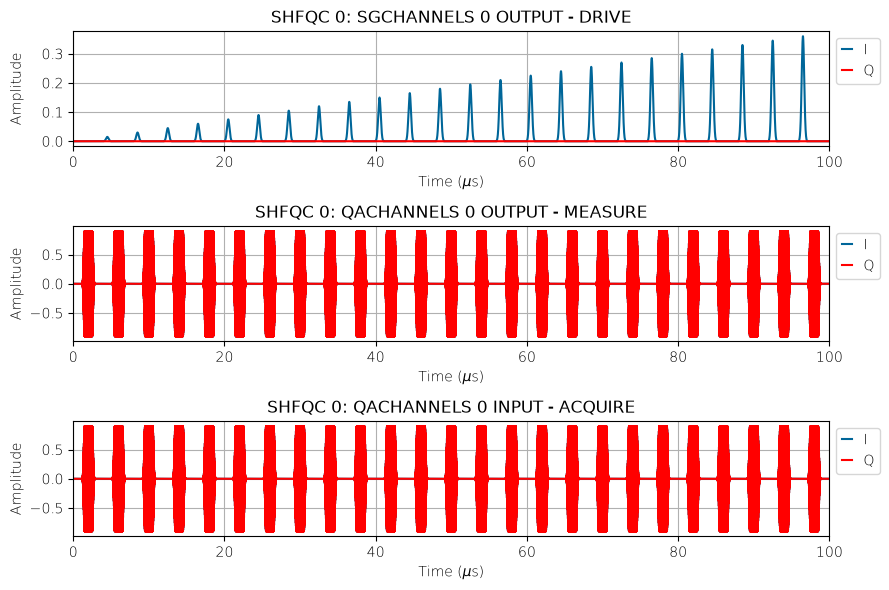

In [8]:
plot_simulation(compiled_rabi, start_time=0, length=100e-6)

### 3.3 Run, Save, and Plot Results

Finally, you'll run the experiment, save, and plot the results.

In [9]:
# run the compiled experiemnt
rabi_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(rabi_results, f"Results/{timestamp}_rabi_results.json")
print(f"File saved as Results/{timestamp}_rabi_results.json")

[2026.06.26 03:31:09.488] INFO    Starting near-time execution...
[2026.06.26 03:31:09.502] INFO    Finished near-time execution.
File saved as Results/20260626T033109_rabi_results.json


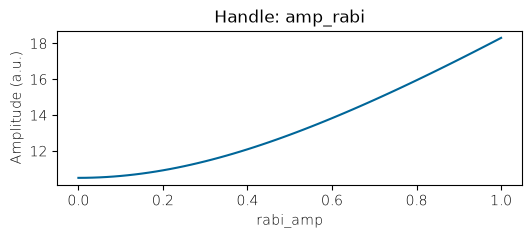

In [10]:
plot_results(rabi_results)

# 4. Fitting Results

You can also fit your results. The below script fits some emulated Rabi data when running in emulation mode.

Fitted parameters: [ 9.97141035 -0.01498598  1.01602257  1.29050808]


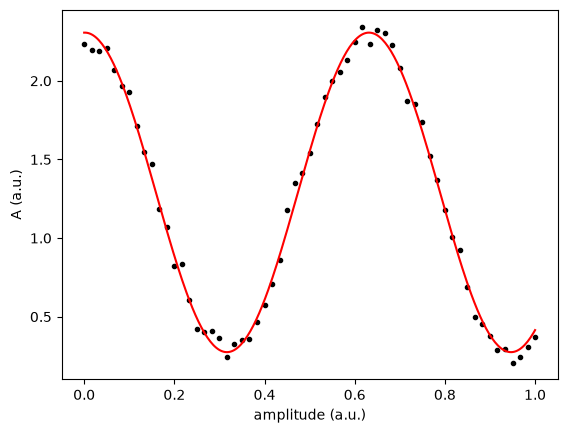

In [11]:
# get measurement data returned by the instruments
rabi_res = rabi_results.get_data("amp_rabi")

# define amplitude axis from qubit parameters
rabi_amp = rabi_results.get_axis("amp_rabi")[0]

if use_emulation:
    # create some dummy data if running in emulation mode
    rabi_res = oscillatory(rabi_amp, 10, 0, 1, 1.2) + 0.2 * np.random.rand(
        len(rabi_amp)
    )

# plot measurement data
fig = plt.figure()
plt.plot(rabi_amp, rabi_res, ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("amplitude (a.u.)")

# increase number of plot points for smooth plotting of fit results
amp_plot = np.linspace(rabi_amp[0], rabi_amp[-1], 5 * len(rabi_amp))

# fit measurement results - assume sinusoidal oscillation with drive amplitude
popt, pcov = oscillatory.fit(rabi_amp, rabi_res, 10, 0, 1, 1.2, plot=False)
print(f"Fitted parameters: {popt}")

# plot fit results together with measurement data
plt.plot(amp_plot, oscillatory(amp_plot, *popt), "-r")
plt.show()